# Rotational Brownian motion: angle PDFs — LAMMPS vs analytics

This notebook compares **single-step PDFs** (probability density functions) from LAMMPS computed with LAMMPS using the conventional **Euler+projection method** and a novel **geometric integrator** with **analytical results** for rotational Brownian motion on the unit sphere.

The one-step PDF $p(\vartheta;\Delta t)$ depends on the relative angle $\vartheta\in[0,\pi]$ and, for free rotational diffusion, on the dimensionless product $D_R\Delta t$, that is, not on $D_R$ and $\Delta t$ separately, where $D_R$ is the rotational diffusion constant and $\Delta t$ the timestep. Let $\mathbf{u}(t)$ denote the particle’s unit orientation at time $t$. The single-step relative angle is $\vartheta=\arccos(\mathbf{u}(t+\Delta t)\cdot\mathbf{u}(t))$, that is, the rotation angle accumulated during one timestep $\Delta t$. Owing to stationarity of rotational Brownian motion, this single-step distribution is identical to the distribution of the angle between $\mathbf{u}(t)$ and $\mathbf{u}(0)$ at time $t=\Delta t$.

**Technical details** and the main **analytical formulas** are summarized below; for details see the reference.

**Reference:**  
Felix Höfling & Arthur V. Straube, *Phys. Rev. Research* **7**, 043034 (2025)  
open access, doi:[10.1103/wzdn-29p4](https://doi.org/10.1103/wzdn-29p4)

### Technical details

We load precomputed `.dat` files from:

- LAMMPS numerics (markers): `data/pdf_lammps_{proj,geom}_Dr..._dt....dat`
- Analytics (lines): `data/pdf_analyt_{exact,proj,geom}_Dr..._dt....dat`

created by:

- `scripts/compute_pdf_from_angles.py` (LAMMPS numerics)
- `scripts/compute_pdf_analytic.py` (analytic PDFs)

Since the theory depends on the product $D_R\Delta t$, we fix $D_R$ and vary the timestep $\Delta t$ in the numerical comparisons; thus smaller (larger) timestep below refers to smaller (larger) values of $D_R\Delta t$.

We plot the rescaled angle $x=\vartheta/\pi$ on the horizontal axis and the one-step PDF $p(\vartheta;\Delta t)$ on the vertical axis.  
Notation in code: `theta` $\leftrightarrow \vartheta$, `Dr` $\leftrightarrow D_R$.

### Analytical formulas (for reference)

**Exact (Eq. 38)**  (here, $P_\ell$ is the Legendre polynomial of degree $\ell$):
$$
p_{\mathrm{exact}}(\vartheta;\Delta t)=\tfrac12 \sin\vartheta\sum_{\ell=0}^{\infty}(2\ell+1)P_\ell(\cos\vartheta)\,{\mathrm e}^{-\ell(\ell+1)D_R\Delta t}
$$

**Geometric scheme (Eq. 41):**
$$
p_{\mathrm{geom}}(\vartheta;\Delta t)=\sum_{k=0}^{\infty}\frac{\vartheta+2\pi k}{2D_R\Delta t}{\mathrm e}^{-(\vartheta+2\pi k)^2/(4D_R\Delta t)}
+\sum_{k=1}^{\infty}\frac{2\pi k-\vartheta}{2D_R\Delta t}{\mathrm e}^{-(2\pi k-\vartheta)^2/(4D_R\Delta t)}
$$

**Euler + projection scheme (Eq. 44):**  
For $0\le\vartheta<\pi/2$,
$$
p_{\mathrm{proj}}(\vartheta;\Delta t)=
\frac{\sin\vartheta}{2D_R\Delta t\cos^3\vartheta}\exp\!\left[-\frac{\cos^{-2}\vartheta-1}{4D_R\Delta t}\right]
$$
and $p_{\mathrm{proj}}(\vartheta;\Delta t)=0$ for $\pi/2\le\vartheta\le\pi$.

In practice we truncate the sums at finite $\ell_\max$ and $k_\max$; see the python script.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- paths ---
repo_root = Path("..").resolve()
data_dir = repo_root / "data"
figs_dir = repo_root / "figs"
figs_dir.mkdir(exist_ok=True)

# --- color palette ---
COL_EXACT     = "#ed1717"   # analytics, exact (red)
COL_PROJ      = "#ffb000"   # analytics, projection (yellow)
COL_GEOM      = "#0295FF"   # analytics, geometric (light blue)
COL_PROJ_MARK =  COL_PROJ   # Lammps, projection 
COL_GEOM_MARK =  COL_GEOM   # Lammps, geometric

def fmt_float(x: float) -> str:
    """Match the convention on numbers in the filename."""
    # --- current behavior: keep one decimal for integer-like values ---
    if float(x).is_integer():
        return f"{x:.1f}"      # 3, 3.0 or 3.00 -> "3.0"
    # compact representation for non-integer values
    return f"{x:.8g}"          # 0.01 -> "0.01"
    # ------------------------------------------------------------------
    # Alternative behavior (shorter; uncomment and remove the code above):
    # works as 3, 3.0 or 3.00 -> "3" otherwise 0.01 -> "0.01"
    # return f"{x:.8g}"     # compact representation applies to all values


def load_xy(path: Path):
    """Load 2-column .dat with '#' comments: returns (theta, pdf)."""
    theta, pdf = np.loadtxt(path, comments="#", unpack=True)
    return theta, pdf


In [3]:
def plot_compare_pdf(ax, *, Dr: float, dt: float,
                     # setting default values, override when calling if required:
                     xlim=(0.0, 1.0),                         # axis settings for the rescaled angle, theta/pi
                     lw_exact=7.0, lw_proj=3.0, lw_geom=2.0,  # line widths 
                     step_proj=2, step_geom=2,                # marker thinning (plot each step_geom|proj point)
                     ms_proj=4.8, ms_geom=4.5,                # marker size
                     ):
    """
    Plot one comparison of PDFs P(theta; dt) agaist the rescaled angle (theta/pi) for given Dr and dt:
      - analytic exact/geom/proj (lines)
      - LAMMPS projection/geometric (markers).
    """

    Dr_str = fmt_float(Dr)
    dt_str = fmt_float(dt)

    # --- file paths (must match the produced filenames) ---
    fa_exact = data_dir / f"pdf_analyt_exact_Dr{Dr_str}_dt{dt_str}.dat"
    fa_proj  = data_dir / f"pdf_analyt_proj_Dr{Dr_str}_dt{dt_str}.dat"
    fa_geom  = data_dir / f"pdf_analyt_geom_Dr{Dr_str}_dt{dt_str}.dat"

    fl_proj  = data_dir / f"pdf_lammps_proj_Dr{Dr_str}_dt{dt_str}.dat"
    fl_geom  = data_dir / f"pdf_lammps_geom_Dr{Dr_str}_dt{dt_str}.dat"

    # --- analytic curves (lines) ---
    th, p = load_xy(fa_exact); ax.plot(th/np.pi, p, color=COL_EXACT, lw=lw_exact, label="Analytic, exact")
    th, p = load_xy(fa_proj);  ax.plot(th/np.pi, p, color=COL_PROJ,  lw=lw_proj,  label="Analytic, projection")
    th, p = load_xy(fa_geom);  ax.plot(th/np.pi, p, color=COL_GEOM,  lw=lw_geom,  label="Analytic, geometric")

    # --- LAMMPS projection (markers) ---
    th, p = load_xy(fl_proj)
    x = th/np.pi
    ax.plot(x[::step_proj],
            p[::step_proj],
            linestyle="none",
            marker="o",
            markersize=ms_proj,
            markeredgewidth=0.5,
            markeredgecolor="black",
            markerfacecolor=COL_PROJ_MARK,
            label="LAMMPS, projection")

    # --- LAMMPS geometric (markers) ---
    th, p = load_xy(fl_geom)
    x = th/np.pi
    ax.plot(x[::step_geom],
            p[::step_geom],
            linestyle="none",
            marker="s",
            markersize=ms_geom,
            markeredgewidth=0.5,
            color="black",
            markerfacecolor=COL_GEOM_MARK,                
            label="LAMMPS, geometric")

# --- axes & legend (common defaults; customize after calling if needed) ---
    ax.set_xlabel(r"$\theta/\pi$")
    ax.set_ylabel(r"$p(\theta; \Delta t)$")
    ax.set_xlim(*xlim)
    ax.legend(frameon=False)

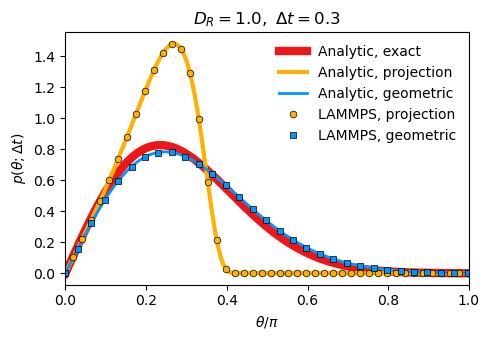

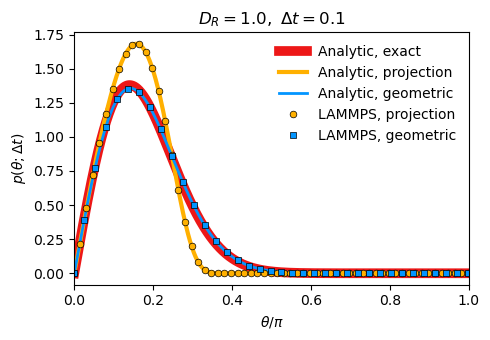

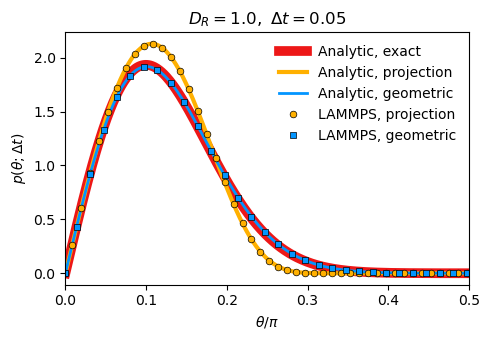

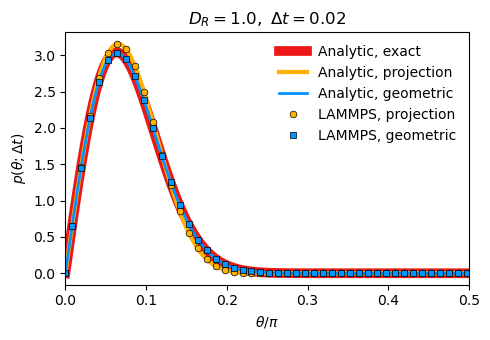

In [4]:
# Make few plots to compare PDFs at different timesteps

Dr = 1.0  # rotational diffusion constant

# --- dt = 0.3: full range, theta/pi in [0, 1] ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.3, xlim=(0,1), step_proj=4, step_geom=6, lw_exact=6.0)
ax.set_title(r"$D_R=1.0,\ \Delta t=0.3$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.3_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.3_comparison.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.1: full range, theta/pi in [0, 1] ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.1, xlim=(0,1), step_proj=3, step_geom=5)
ax.set_title(r"$D_R=1.0,\ \Delta t=0.1$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.1_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.1_comparison.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.05: zoom to theta/pi in [0, 0.5] ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.05, xlim=(0,0.5), step_proj=2, step_geom=3)
ax.set_title(r"$D_R=1.0,\ \Delta t=0.05$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.05_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.05_comparison.pdf", bbox_inches="tight")
plt.show()

# --- dt = 0.02: zoom to theta/pi in [0, 0.5] ---
fig, ax = plt.subplots(figsize=(5, 3.5))
plot_compare_pdf(ax, Dr=Dr, dt=0.02, xlim=(0,0.5), step_proj=2, step_geom=2)
ax.set_title(r"$D_R=1.0,\ \Delta t=0.02$")
fig.tight_layout()
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.02_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(figs_dir / "pdf_Dr1.0_dt0.02_comparison.pdf", bbox_inches="tight")
plt.show()


## Observations

- For sufficiently small timesteps $\Delta t$ (at fixed $D_R$), the PDFs obtained with both the Euler+projection and geometric integrators agree well with the exact analytical one-step PDF over the full range of $\vartheta$.
- The Euler+projection scheme exhibits the characteristic cutoff at $\vartheta=\pi/2$ (no weight for $\vartheta\ge\pi/2$), consistent with Eq. (44).
- As $\Delta t$ is increased, the Euler+projection PDF deviates significantly from the analytical result, whereas the geometric integrator remains close to the analytical PDF even at comparatively large timesteps.

Recall that from theory the one-step PDF depends only on $D_R\Delta t$; here we fix $D_R$ and vary $\Delta t$ to probe timestep effects.
